In [1]:
#import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import seaborn as sns


In [ ]:
#retrieve relevant datasets
oxidative_stress = pd.read_excel("C:/Users/user/Desktop/gitEDAML/EDA.ML_Stat_Models/ML/Breast_Cancer_Class_Detect/clinical_cleaned_data.xlsx", usecols=['cases.case_id', 'cases.submitter_id', 'Oxidative stress present?'])
clinical_stats = pd.read_csv("C:/Users/user/Desktop/gitEDAML/EDA.ML_Stat_Models/ML/Breast_Cancer_Class_Detect/Clinical_Info.csv")
print(oxidative_stress)

In [ ]:
#doing data cleaning and merging of the cleaned datasets
oxidative_stress['Oxidative stress present?'] = oxidative_stress['Oxidative stress present?'].str.replace('n', 'N')
oxidative_stress_na = oxidative_stress[oxidative_stress['Oxidative stress present?'].isna() == False]
#print(oxidative_stress_na.columns, oxidative_stress.columns)
oxidative_stress_clean = oxidative_stress_na.drop_duplicates(subset=['cases.case_id','cases.submitter_id'])
pd.options.display.max_columns = None
pd.options.display.max_rows = None
#print(oxidative_stress_clean.isnull().sum())
#print(clinical_stats.columns)


def cancerclassstrtoint(input):
    final = 0
    if not input:
        return None
    if type(input) == float:
        return input
    for i in input:
        #cancer has only 4 stages. So if there is a V, just return 4
        if i == 'V':
            return int(4)
        #do counter for all the other Is
        elif i == 'I':
            final += 1
        else:
            pass
    return final

clinical_stats['diagnoses.ajcc_pathologic_stage'] = clinical_stats['diagnoses.ajcc_pathologic_stage'].apply(cancerclassstrtoint)

for row in clinical_stats.iterrows():
    #print(row[1]['diagnoses.ajcc_pathologic_stage'], end=' ')
    row[1]['diagnoses.ajcc_pathologic_stage'] = cancerclassstrtoint(row[1]['diagnoses.ajcc_pathologic_stage'])
    #print(row[1]['diagnoses.ajcc_pathologic_stage'])

#do merge of clinical stats with the oxidative stress data based on the case id and submitter id
oxidative_str_fin = oxidative_stress_clean.merge(clinical_stats, how='left', on=['cases.case_id'])
print(oxidative_str_fin['diagnoses.ajcc_pathologic_stage'])

<Figure size 8000x4000 with 0 Axes>

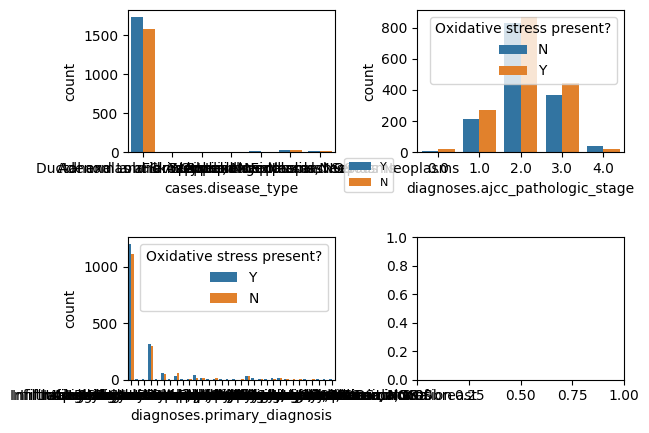

In [23]:
#boxplots to see any variability of breast cancer patients with related oxidative stress vs no related
plt.figure(figsize=(80,40))
fig, ax = plt.subplots(2,2)

plt.subplots_adjust(
    wspace=0.4,
    hspace=0.6
)

#check the columns in the combined cleaned dataset
"""
cases.disease_type - to see if there might be any correlation with oxidative stress according to site of carcinoma retrieval
demographic.age_at_index - age has relation or any correlation?
diagnoses.ajcc_pathologic_stage - i need this since it is my original intention for the project
diagnoses.primary_diagnosis - this has an analysis of the particular area in which the carcinoma is received.
"""

disease_type = sns.countplot(data = oxidative_str_fin, hue='Oxidative stress present?', x='cases.disease_type', ax=ax[0,0])
ax[0,0].legend(loc='upper left', bbox_to_anchor=(1.02,0), fontsize=8)


disease_class = sns.countplot(data= oxidative_str_fin, x='diagnoses.ajcc_pathologic_stage', hue='Oxidative stress present?', ax=ax[0,1])

disease_loc = sns.countplot(data=oxidative_str_fin, x='diagnoses.primary_diagnosis', hue='Oxidative stress present?', ax=ax[1,0])


In [ ]:
"""
Conclusion: seems like if the cancer possess oxidative stress is purely due to chance 
Hard to finalize if a specific class will have oxidative stress or not since some cancerous cells do not
really show evidence of oxidative stress
"""